### Code Challenge: Fourier Transform via Matrix Multiplication

In [58]:
# ======================================================================
# SECTION: FOURIER TRANSFORM VIA MATRIX MULTIPLICATION
# COMPLEXITY: O(n^2) - Matrix construction and Matrix-Vector product.
# DATA SHAPE: F(n, n), x(n) -> Result X(n).
# MATH: F_{jk} = \omega^{j \cdot k} where \omega = e^{-2\pi i / n}.
# TOOLS: np.arange(), np.exp(), np.fft.fft(), plt.subplots()
# ======================================================================

import numpy as np
import matplotlib.pyplot as plt

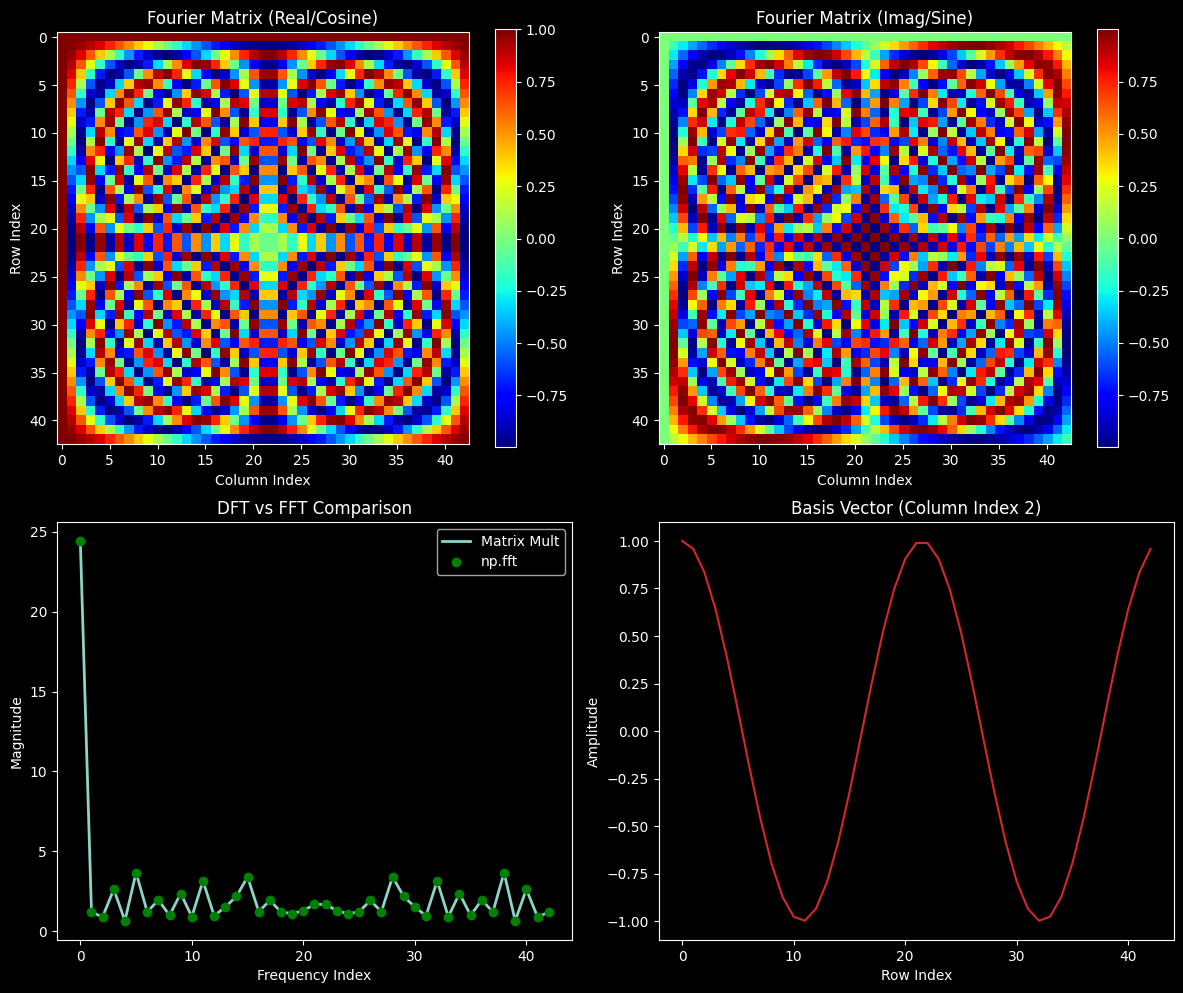

In [75]:
# Build the Fourier matrix and compare matrix multiplication with NumPy's FFT.
n = 43
j = np.arange(n)[:, None]
k = np.arange(n)[None, :]
omega = np.exp(-2 * np.pi * 1j / n)
F = omega ** (j * k)

x = np.random.rand(n)
X1 = F @ x
X2 = np.fft.fft(x)
assert np.allclose(X1, X2)

# Plot the real/imaginary parts of the Fourier matrix and compare DFT magnitudes.
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

im1 = axs[0, 0].imshow(F.real, cmap='jet')
axs[0, 0].set_title("Fourier Matrix (Real/Cosine)")
axs[0, 0].set_xlabel("Column Index")
axs[0, 0].set_ylabel("Row Index")
fig.colorbar(im1, ax=axs[0, 0])

im2 = axs[0, 1].imshow(F.imag, cmap='jet')
axs[0, 1].set_title("Fourier Matrix (Imag/Sine)")
axs[0, 1].set_xlabel("Column Index")
axs[0, 1].set_ylabel("Row Index")
fig.colorbar(im2, ax=axs[0, 1])

axs[1, 0].plot(abs(X1), label='Matrix Mult', linewidth=2)
axs[1, 0].plot(abs(X2), marker='o', color='g', linestyle='None', label='np.fft')
axs[1, 0].set_title("DFT vs FFT Comparison")
axs[1, 0].set_xlabel("Frequency Index (DFT bin number)")
axs[1, 0].set_ylabel("Magnitude (absolute transform value)")
axs[1, 0].legend()

# Show one Fourier basis vector.
axs[1, 1].plot(F.real[:, 2], color='tab:red')
axs[1, 1].set_title("Basis Vector (Column Index 2)")
axs[1, 1].set_xlabel("Row Index (sample position)")
axs[1, 1].set_ylabel("Amplitude (real part of basis value)")

plt.tight_layout()
plt.show()
